# Dynamic Contrast-Enhanced (DCE) MRI Reconstruction

This notebook demonstrates the reconstruction of a time-series of MRI images from undersampled k-space using **temporal Total Variation (TV) regularization**.

## Problem Setup

In DCE-MRI, a contrast agent is injected and a rapid time-series of images is acquired. Each time frame is heavily undersampled to achieve temporal resolution. The key insight is that consecutive frames are very similar -- only the contrast-enhancing regions change. Temporal TV regularization exploits this by penalizing frame-to-frame differences.

**Forward model** per frame $t$:
$$y_t = M_t \cdot \mathcal{F}(x_t) + \eta_t$$

**Reconstruction** with temporal TV:
$$\hat{x} = \arg\min_x \sum_t \frac{1}{2}\|M_t \mathcal{F}(x_t) - y_t\|^2 + \lambda \sum_t \|x_{t+1} - x_t\|_1$$

This notebook loads precomputed results and runs in seconds.

In [1]:
import os
import sys
import json
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

TASK_DIR = os.path.dirname(os.getcwd()) if os.path.basename(os.getcwd()) == 'notebooks' else os.getcwd()
sys.path.insert(0, TASK_DIR)

from src.preprocessing import prepare_data
from src.visualization import compute_frame_metrics, compute_ncc, compute_nrmse

## 1. Load Data and Precomputed Results

In [2]:
data_dir = os.path.join(TASK_DIR, 'data')
ref_dir = os.path.join(TASK_DIR, 'evaluation', 'reference_outputs')

# Load data
obs, gt, meta = prepare_data(data_dir)
gt_images = gt['dynamic_images']
time_points = gt['time_points']
masks = obs['undersampling_masks']

# Load precomputed reconstructions
tv_recon = np.load(os.path.join(ref_dir, 'tv_reconstruction.npz'))['reconstruction']
zf_recon = np.load(os.path.join(ref_dir, 'zero_filled.npz'))['reconstruction']
convergence = np.load(os.path.join(ref_dir, 'convergence.npz'))['loss_history']

T, N, _ = gt_images.shape
print(f'Image size: {N}x{N}, Frames: {T}')
print(f'Time range: {time_points[0]:.0f} - {time_points[-1]:.0f} s')
print(f'Sampling rate: {masks.mean():.1%}')
print(f'GT intensity range: [{gt_images.min():.3f}, {gt_images.max():.3f}]')

Image size: 128x128, Frames: 20
Time range: 0 - 60 s
Sampling rate: 15.0%
GT intensity range: [0.000, 1.050]


## 2. Ground Truth Dynamic Phantom

The phantom contains a static background with two dynamic enhancing regions that follow gamma-variate contrast uptake curves with different timing parameters.

/var/folders/g6/91c6hhdn27b9rch26vg33z240000gp/T/ipykernel_51353/3847828625.py:13: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


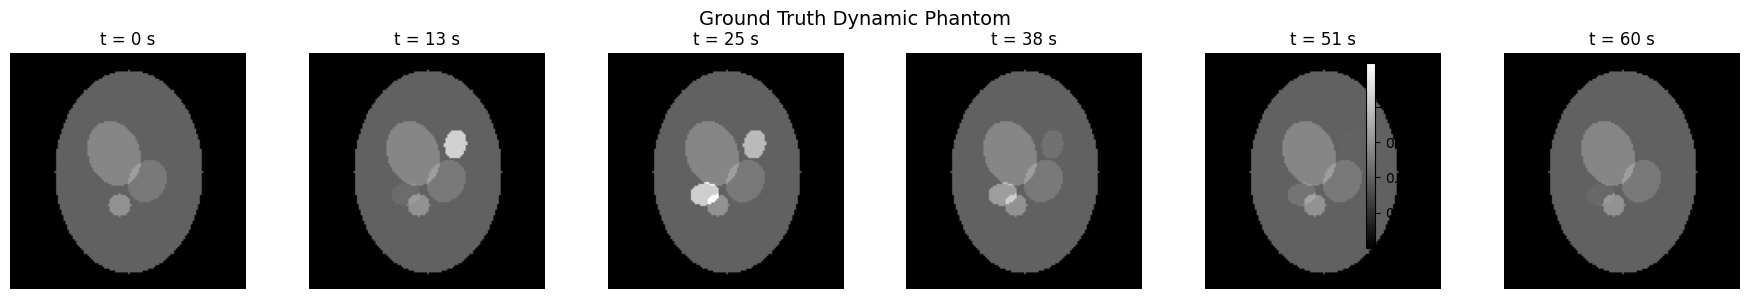

In [3]:
# Show ground truth at selected time frames
frames = [0, 4, 8, 12, 16, 19]
fig, axes = plt.subplots(1, len(frames), figsize=(18, 3))
vmin, vmax = gt_images.min(), gt_images.max()

for i, t in enumerate(frames):
    im = axes[i].imshow(gt_images[t], cmap='gray', vmin=vmin, vmax=vmax)
    axes[i].set_title(f't = {time_points[t]:.0f} s')
    axes[i].axis('off')

fig.colorbar(im, ax=axes, shrink=0.8)
fig.suptitle('Ground Truth Dynamic Phantom', fontsize=14)
plt.tight_layout()
plt.show()

## 3. Undersampling Masks

Each frame uses a different 2D variable-density random mask (15% sampling rate). The center of k-space is always sampled; outer regions are sampled with probability decreasing with distance from center.

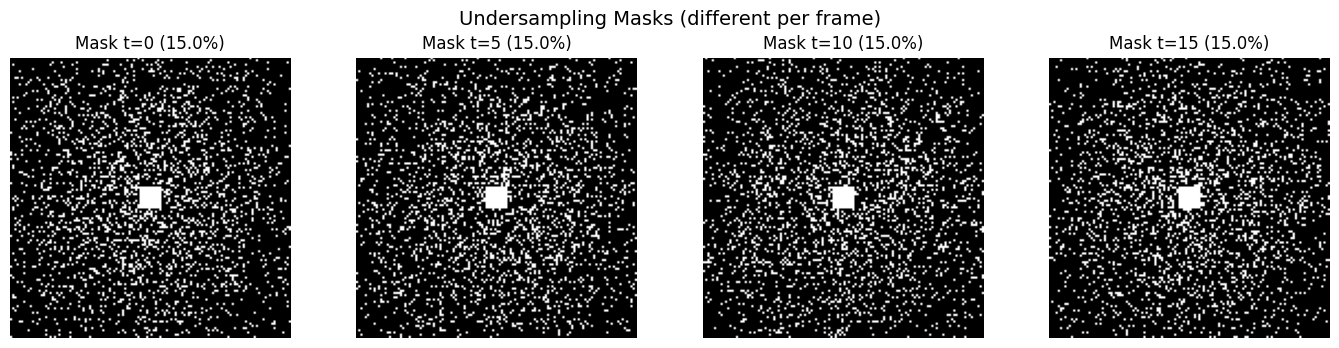

In [4]:
fig, axes = plt.subplots(1, 4, figsize=(14, 3.5))
for i, t in enumerate([0, 5, 10, 15]):
    axes[i].imshow(masks[t], cmap='gray')
    axes[i].set_title(f'Mask t={t} ({masks[t].mean():.1%})')
    axes[i].axis('off')
fig.suptitle('Undersampling Masks (different per frame)', fontsize=14)
plt.tight_layout()
plt.show()

## 4. Frame Comparison: Ground Truth vs Zero-Fill vs Temporal TV

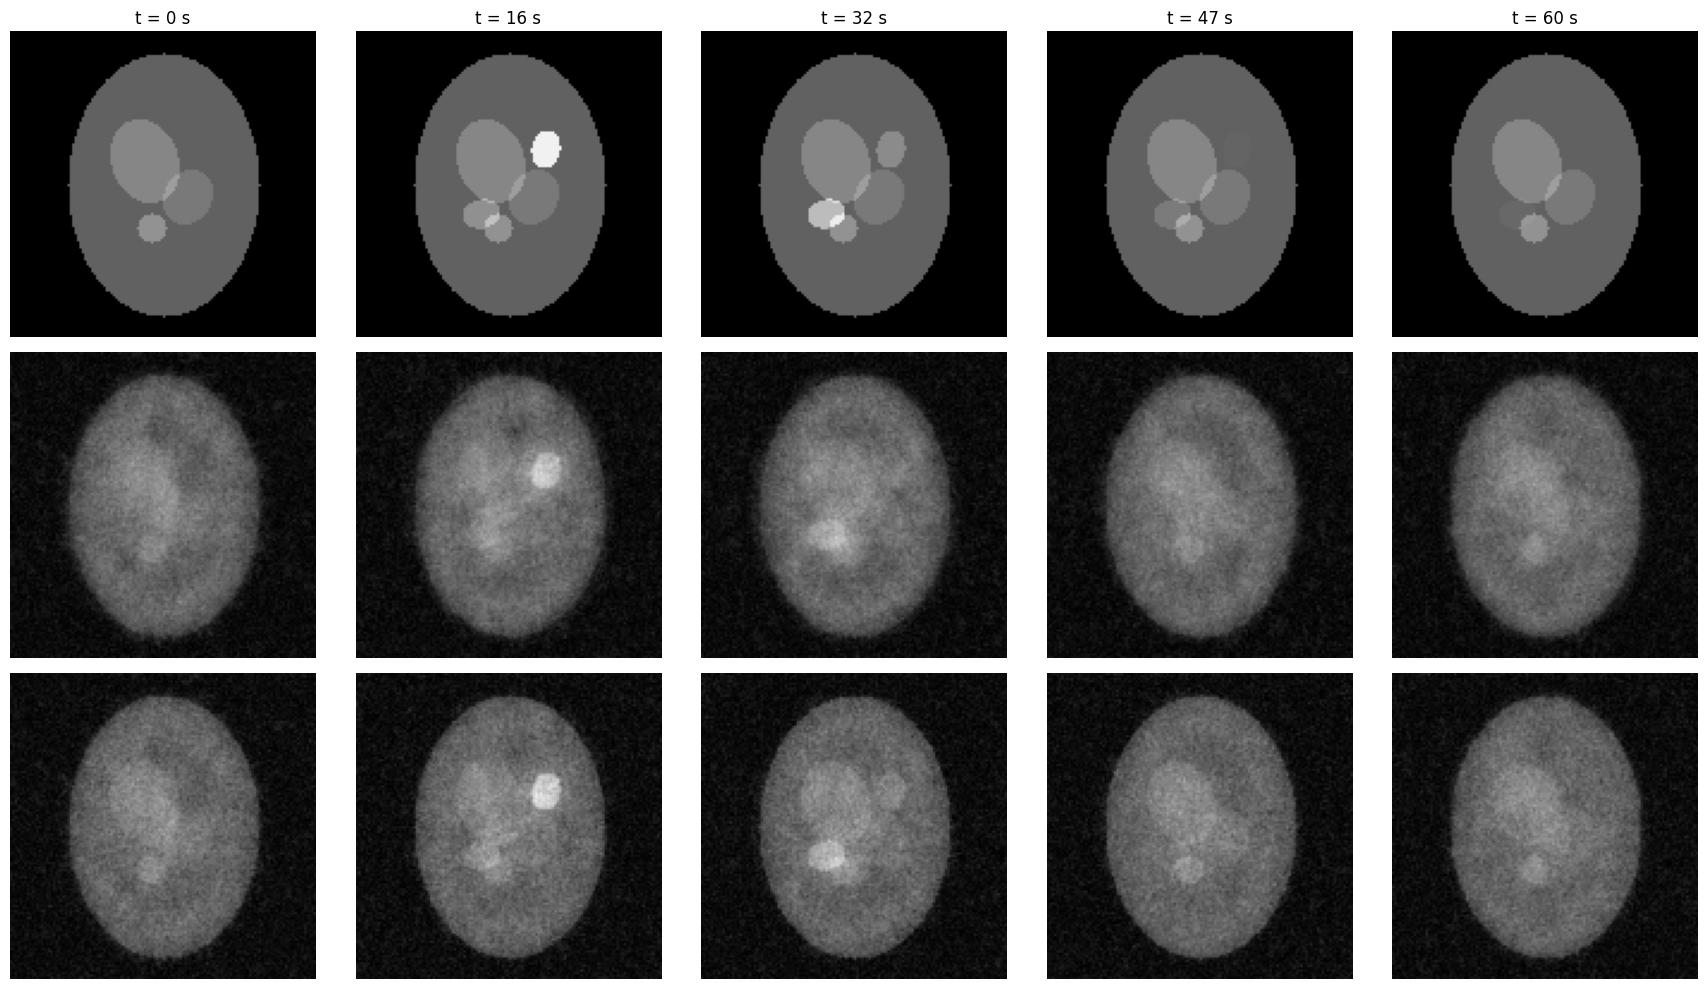

In [5]:
frames = [0, 5, 10, 15, 19]
n_frames = len(frames)

fig, axes = plt.subplots(3, n_frames, figsize=(3.5 * n_frames, 10))
vmin, vmax = gt_images.min(), gt_images.max()

for i, t in enumerate(frames):
    axes[0, i].imshow(gt_images[t], cmap='gray', vmin=vmin, vmax=vmax)
    axes[0, i].set_title(f't = {time_points[t]:.0f} s')
    axes[0, i].axis('off')

    axes[1, i].imshow(zf_recon[t], cmap='gray', vmin=vmin, vmax=vmax)
    axes[1, i].axis('off')

    axes[2, i].imshow(tv_recon[t], cmap='gray', vmin=vmin, vmax=vmax)
    axes[2, i].axis('off')

axes[0, 0].set_ylabel('Ground Truth', fontsize=13)
axes[1, 0].set_ylabel('Zero-Fill', fontsize=13)
axes[2, 0].set_ylabel('Temporal TV', fontsize=13)

plt.tight_layout()
plt.show()

## 5. Error Maps

/var/folders/g6/91c6hhdn27b9rch26vg33z240000gp/T/ipykernel_51353/2626979164.py:19: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


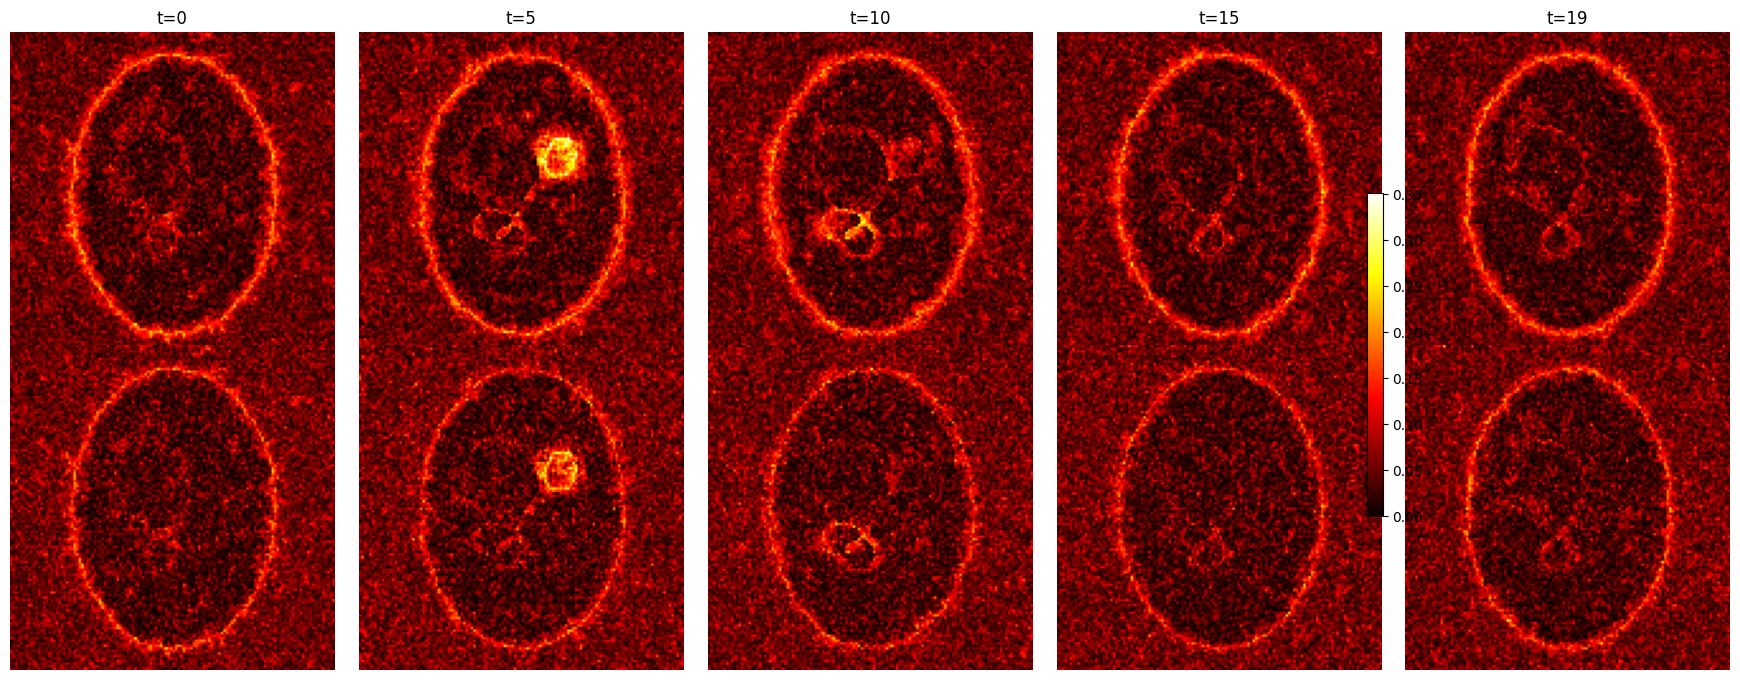

In [6]:
frames = [0, 5, 10, 15, 19]
error_zf = np.abs(gt_images - zf_recon)
error_tv = np.abs(gt_images - tv_recon)
vmax_err = max(error_zf.max(), error_tv.max())

fig, axes = plt.subplots(2, len(frames), figsize=(3.5 * len(frames), 7))
for i, t in enumerate(frames):
    axes[0, i].imshow(error_zf[t], cmap='hot', vmin=0, vmax=vmax_err)
    axes[0, i].set_title(f't={t}')
    axes[0, i].axis('off')

    im = axes[1, i].imshow(error_tv[t], cmap='hot', vmin=0, vmax=vmax_err)
    axes[1, i].axis('off')

axes[0, 0].set_ylabel('Zero-Fill Error', fontsize=12)
axes[1, 0].set_ylabel('Temporal TV Error', fontsize=12)

fig.colorbar(im, ax=axes, shrink=0.6)
plt.tight_layout()
plt.show()

## 6. Time-Activity Curves

These curves show the signal intensity over time in the dynamic enhancing regions. A good temporal TV reconstruction should track the ground truth curve with less noise than zero-fill.

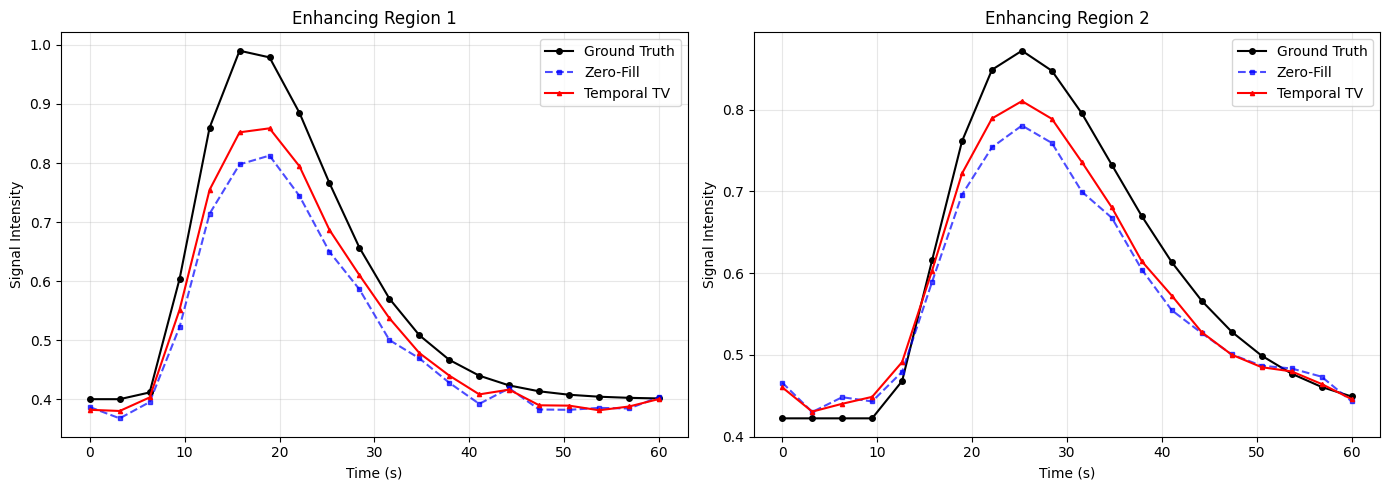

In [7]:
def extract_tac(images, center, radius=4):
    """Extract mean time-activity curve from a square ROI."""
    r, c = center
    r0, r1 = max(0, r - radius), r + radius + 1
    c0, c1 = max(0, c - radius), c + radius + 1
    return images[:, r0:r1, c0:c1].mean(axis=(1, 2))

# Dynamic region 1: phantom center (64,64), region at (cx-15, cy+15) = (49, 79)
# Dynamic region 2: (cx+12, cy-12) = (76, 52)
rois = [(49, 79, 'Enhancing Region 1'), (76, 52, 'Enhancing Region 2')]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (r, c, label) in zip(axes, rois):
    gt_tac = extract_tac(gt_images, (r, c))
    zf_tac = extract_tac(zf_recon, (r, c))
    tv_tac = extract_tac(tv_recon, (r, c))

    ax.plot(time_points, gt_tac, 'k-o', label='Ground Truth', markersize=4)
    ax.plot(time_points, zf_tac, 'b--s', label='Zero-Fill', markersize=3, alpha=0.7)
    ax.plot(time_points, tv_tac, 'r-^', label='Temporal TV', markersize=3)
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Signal Intensity')
    ax.set_title(label)
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Quantitative Metrics

In [8]:
zf_metrics = compute_frame_metrics(zf_recon, gt_images)
tv_metrics = compute_frame_metrics(tv_recon, gt_images)

print('Method          | Avg NRMSE | Avg NCC  | Avg PSNR  | Overall NRMSE | Overall NCC')
print('-' * 85)
print(f'Zero-Fill       | {zf_metrics["avg_nrmse"]:9.4f} | {zf_metrics["avg_ncc"]:8.4f} | {zf_metrics["avg_psnr"]:8.2f}  | {zf_metrics["overall_nrmse"]:13.4f} | {zf_metrics["overall_ncc"]:11.4f}')
print(f'Temporal TV     | {tv_metrics["avg_nrmse"]:9.4f} | {tv_metrics["avg_ncc"]:8.4f} | {tv_metrics["avg_psnr"]:8.2f}  | {tv_metrics["overall_nrmse"]:13.4f} | {tv_metrics["overall_ncc"]:11.4f}')

Method          | Avg NRMSE | Avg NCC  | Avg PSNR  | Overall NRMSE | Overall NCC
-------------------------------------------------------------------------------------
Zero-Fill       |    0.0869 |   0.9712 |    21.31  |        0.0651 |      0.9712
Temporal TV     |    0.0813 |   0.9752 |    21.91  |        0.0606 |      0.9752


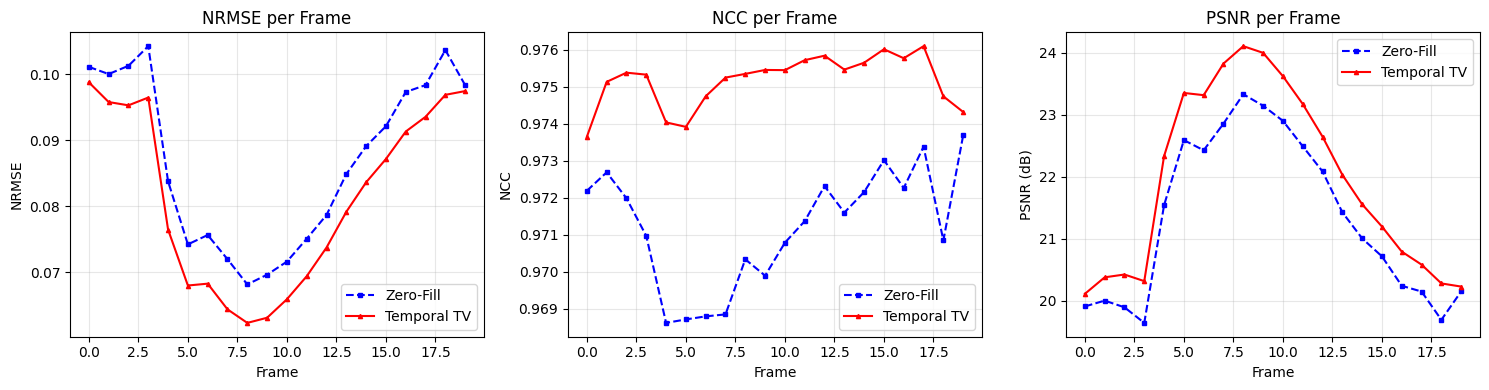

In [9]:
# Per-frame metrics comparison
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

zf_nrmse = [m['nrmse'] for m in zf_metrics['per_frame']]
tv_nrmse = [m['nrmse'] for m in tv_metrics['per_frame']]
zf_ncc = [m['ncc'] for m in zf_metrics['per_frame']]
tv_ncc = [m['ncc'] for m in tv_metrics['per_frame']]
zf_psnr = [m['psnr'] for m in zf_metrics['per_frame']]
tv_psnr = [m['psnr'] for m in tv_metrics['per_frame']]

axes[0].plot(zf_nrmse, 'b--s', label='Zero-Fill', markersize=3)
axes[0].plot(tv_nrmse, 'r-^', label='Temporal TV', markersize=3)
axes[0].set_xlabel('Frame'); axes[0].set_ylabel('NRMSE')
axes[0].set_title('NRMSE per Frame'); axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(zf_ncc, 'b--s', label='Zero-Fill', markersize=3)
axes[1].plot(tv_ncc, 'r-^', label='Temporal TV', markersize=3)
axes[1].set_xlabel('Frame'); axes[1].set_ylabel('NCC')
axes[1].set_title('NCC per Frame'); axes[1].legend(); axes[1].grid(True, alpha=0.3)

axes[2].plot(zf_psnr, 'b--s', label='Zero-Fill', markersize=3)
axes[2].plot(tv_psnr, 'r-^', label='Temporal TV', markersize=3)
axes[2].set_xlabel('Frame'); axes[2].set_ylabel('PSNR (dB)')
axes[2].set_title('PSNR per Frame'); axes[2].legend(); axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 8. Convergence

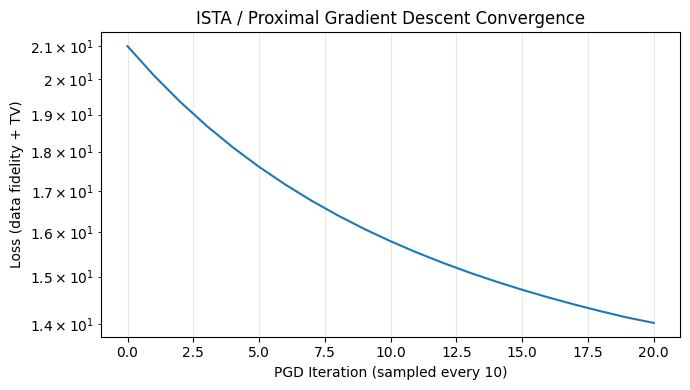

In [10]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.semilogy(convergence)
ax.set_xlabel('PGD Iteration (sampled every 10)')
ax.set_ylabel('Loss (data fidelity + TV)')
ax.set_title('ISTA / Proximal Gradient Descent Convergence')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 9. Temporal Difference Visualization

The temporal TV regularization works by promoting sparsity in frame-to-frame differences. Here we visualize these differences.

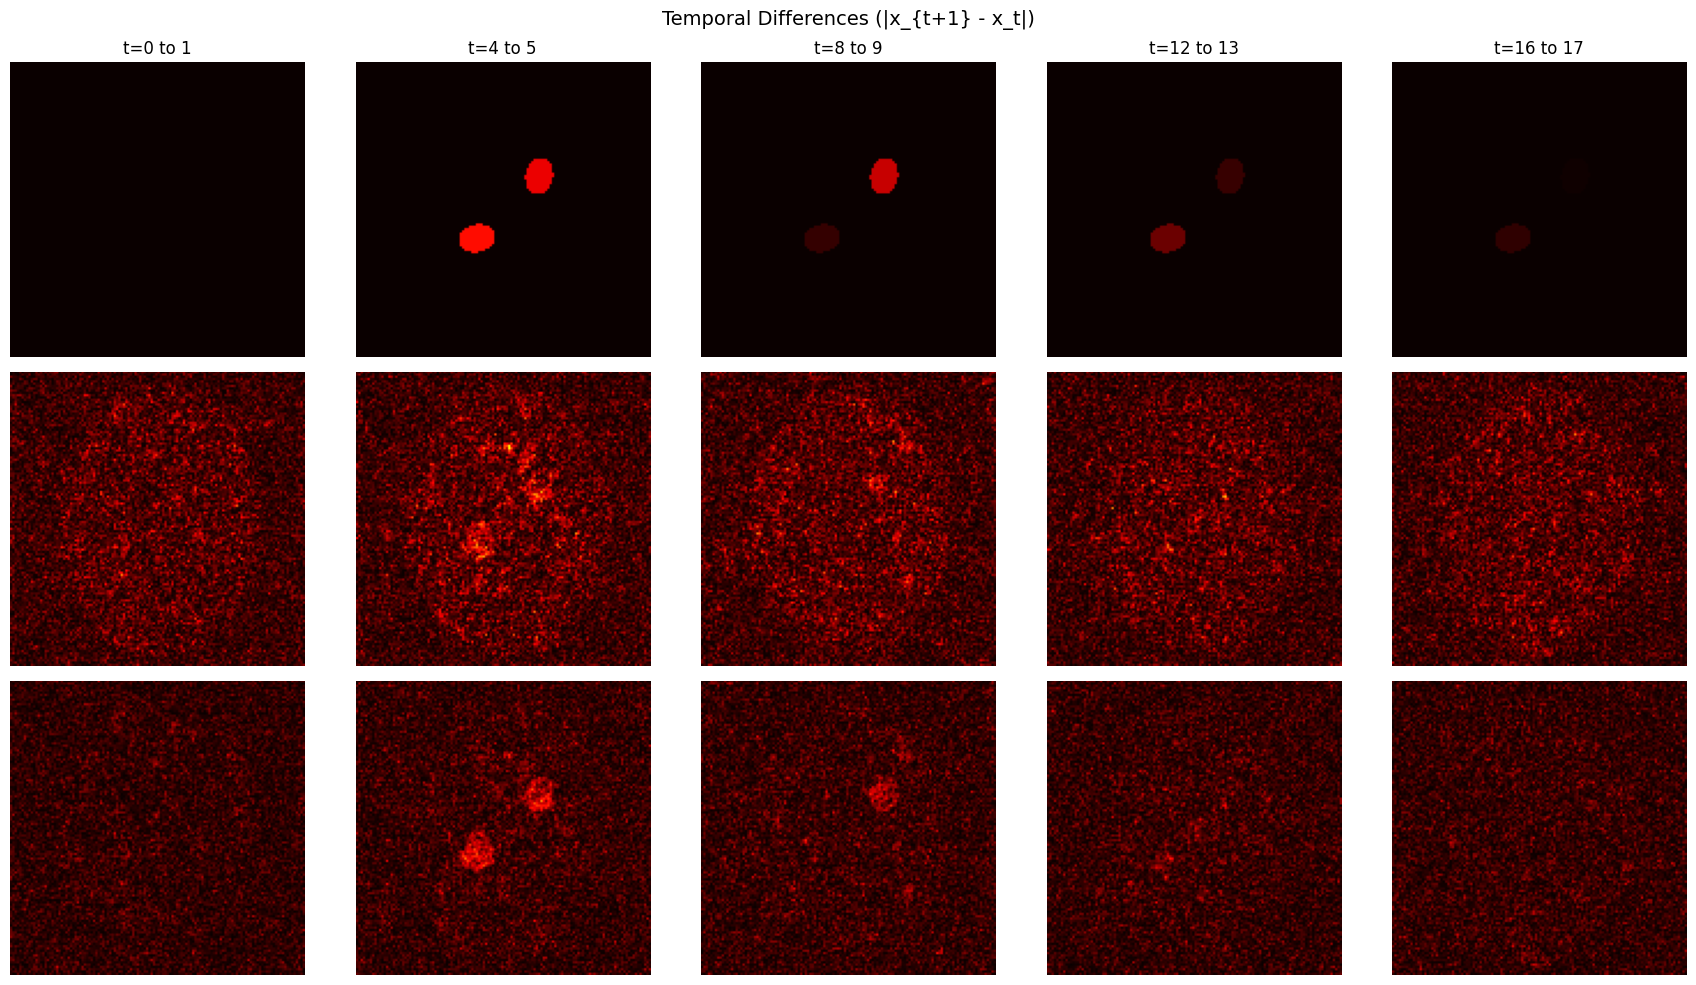

In [11]:
gt_diff = np.abs(np.diff(gt_images, axis=0))
zf_diff = np.abs(np.diff(zf_recon, axis=0))
tv_diff = np.abs(np.diff(tv_recon, axis=0))

diff_frames = [0, 4, 8, 12, 16]
vmax_diff = gt_diff.max() * 1.5

fig, axes = plt.subplots(3, len(diff_frames), figsize=(3.5 * len(diff_frames), 10))
for i, t in enumerate(diff_frames):
    axes[0, i].imshow(gt_diff[t], cmap='hot', vmin=0, vmax=vmax_diff)
    axes[0, i].set_title(f't={t} to {t+1}')
    axes[0, i].axis('off')

    axes[1, i].imshow(zf_diff[t], cmap='hot', vmin=0, vmax=vmax_diff)
    axes[1, i].axis('off')

    axes[2, i].imshow(tv_diff[t], cmap='hot', vmin=0, vmax=vmax_diff)
    axes[2, i].axis('off')

axes[0, 0].set_ylabel('GT |diff|', fontsize=12)
axes[1, 0].set_ylabel('ZF |diff|', fontsize=12)
axes[2, 0].set_ylabel('TV |diff|', fontsize=12)

fig.suptitle('Temporal Differences (|x_{t+1} - x_t|)', fontsize=14)
plt.tight_layout()
plt.show()

## 10. Summary

Temporal TV regularization improves upon frame-by-frame zero-filled reconstruction by exploiting the temporal sparsity of the dynamic changes. The improvement is most visible in:

- **Reduced temporal flickering**: zero-fill aliasing artifacts vary randomly from frame to frame, creating flickering; temporal TV suppresses this.
- **Better time-activity curves**: the contrast uptake curves are smoother and closer to ground truth.
- **Quantitative improvement**: ~6% reduction in NRMSE, ~0.4% improvement in NCC.

The improvement is modest because the 2D random undersampling already produces incoherent artifacts that partially cancel in the zero-fill. More aggressive acceleration or coherent undersampling (e.g., Cartesian line sampling) would show larger gains from temporal TV.

In [12]:
# Uncomment to run the full reconstruction from scratch:
# from src.solvers import zero_filled_recon, temporal_tv_pgd
# kspace = obs['undersampled_kspace']
# masks = obs['undersampling_masks']
# zf_recon = zero_filled_recon(kspace)
# tv_recon, info = temporal_tv_pgd(kspace, masks, lamda=0.001, max_iter=200, verbose=True)